# Random Forest Interpretability Analysis for Input Loss Landscape (ILL) Features

This notebook provides comprehensive interpretability analysis for Random Forest models trained on Input Loss Landscape features to distinguish between forget, retain, and holdout datasets.

## Analysis Components:
1. **Feature Importance Analysis** - Examine which ILL features are most important
2. **Feature Ablation Study** - Remove features and analyze performance impact
3. **Tree Surrogate Models** - Train interpretable decision trees to approximate RF behavior
4. **Advanced Interpretability** - SHAP, permutation importance, partial dependence plots
5. **Model Comparison** - Compare full vs simplified models

The goal is to understand **why** Random Forest performs better and **which features** are most critical for distinguishing between the three dataset types.

In [28]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score, validation_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance, partial_dependence, PartialDependenceDisplay
import warnings
warnings.filterwarnings('ignore')

# Try to import SHAP for advanced interpretability
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP is available for advanced interpretability")
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available. Install with: pip install shap")

import os
import sys

# Setup paths
curr_dir = os.path.abspath(os.getcwd())
PROJECT_DIR = os.path.abspath(os.path.join(curr_dir, '..', '..', '..'))
Unlearn_Simple_DIR = os.path.join(PROJECT_DIR, 'Unlearn-Simple')
MUSE_DIR = os.path.join(Unlearn_Simple_DIR, 'MUSE')
MUSE_SRC_DIR = os.path.join(MUSE_DIR, 'src')
PROJECT_SRC_DIR = os.path.join(PROJECT_DIR, 'src')

sys.path.append(MUSE_SRC_DIR)
sys.path.append(PROJECT_DIR)
sys.path.append(PROJECT_SRC_DIR)

# Import all our analysis functions from the module
from explore_RF_ILL import (
    prepare_classification_data,
    remove_features_and_evaluate,
    ablation_study_bottom_k,
    ablation_study_top_k,
    train_tree_surrogate,
    run_permutation_importance_analysis,
    analyze_partial_dependence,
    analyze_feature_interactions,
    run_shap_analysis,
    generate_comprehensive_summary
)

SHAP not available. Install with: pip install shap


In [29]:
# Load the evaluation module and prepare data
import eval_with_ILL
import src.utils as project_utils
from input_loss_landscape.utils import *

# Configuration for data loading
raw_or_privleak = 'raw'
subset_len = 500  # Limit for computational efficiency

# Load datasets
forget_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/forget.json')
if raw_or_privleak == 'raw':
    retain_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/retain1.json')
else:
    retain_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/retain.json')
holdout_file = os.path.join(MUSE_DIR, f'data/news/{raw_or_privleak}/holdout.json')

forget_data = eval_with_ILL.read_json(forget_file)[:subset_len]
retain_data = eval_with_ILL.read_json(retain_file)[:subset_len]
holdout_data = eval_with_ILL.read_json(holdout_file)[:subset_len]

print(f"Dataset sizes:")
print(f"  Forget: {len(forget_data)}")
print(f"  Retain: {len(retain_data)}")
print(f"  Holdout: {len(holdout_data)}")

# Model configuration
model_name = "OPTML-Group/SimNPO-MUSE-News-llama-2-7b"
tokenizer_dir = "meta-llama/Llama-2-7b-hf"

print(f"Model: {model_name}")
print(f"Tokenizer: {tokenizer_dir}")

Dataset sizes:
  Forget: 500
  Retain: 500
  Holdout: 500
Model: OPTML-Group/SimNPO-MUSE-News-llama-2-7b
Tokenizer: meta-llama/Llama-2-7b-hf


In [30]:
# Load model and tokenizer
from transformers import AutoModelForCausalLM, AutoTokenizer

# Clean GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

tokenizer = AutoTokenizer.from_pretrained(tokenizer_dir)
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float16, device_map="auto")

print(f"Model loaded on device: {next(model.parameters()).device}")
print(f"Model type: {type(model)}")

# Prepare datasets for ILL analysis
datasets = {
    'forget': {'name': 'forget', 'data': forget_data},
    'retain': {'name': 'retain', 'data': retain_data},
    'holdout': {'name': 'holdout', 'data': holdout_data}
}

# ILL strategy configuration
perc_of_tokens_to_replace = 0.1
n_tokens = int(300 * perc_of_tokens_to_replace)
strategy = {'name': 'embeddings', 'peak_top_k': 20, 'n_tokens': n_tokens, 'max_neighbors': 15}

# Path to precomputed cosine similarities
cosine_similarities_file = os.path.join(PROJECT_DIR, 'models', 'distilgpt2-finetuned-wikitext2', 'embeddings', 'token_knn_mapping_70_cosine.pth')

print(f"ILL Strategy: {strategy}")
print(f"Using cosine similarities from: {cosine_similarities_file}")

Loading checkpoint shards: 100%|██████████| 3/3 [00:02<00:00,  1.06it/s]



Model loaded on device: cuda:0
Model type: <class 'transformers.models.llama.modeling_llama.LlamaForCausalLM'>
ILL Strategy: {'name': 'embeddings', 'peak_top_k': 20, 'n_tokens': 30, 'max_neighbors': 15}
Using cosine similarities from: /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/models/distilgpt2-finetuned-wikitext2/embeddings/token_knn_mapping_70_cosine.pth


In [31]:
# Compute ILL features
print("Computing Input Loss Landscape features...")

new_ILL_eval_kwargs = {
    'model_name': model_name,
    'model': model,
    'tokenizer': tokenizer,
    'datasets': datasets,
    'prompt_column': 'text',
    'create_new_neighbors_file': False,
    'showplts': False,
    'cosine_similarities_file': cosine_similarities_file,
    'plots_output_dir': None,
    'strategy': strategy,
    'output_dirs': {'neighbors': f'{raw_or_privleak}'}
}

features_dict = new_ILL_eval(new_ILL_eval_kwargs)

print("ILL features computed successfully!")
print(f"Feature dictionary keys: {features_dict.keys()}")
print(f"Features for 'forget': {features_dict['forget']['unnormalized_features_tensor'].shape}")

# Extract and normalize features
forget_tensor = features_dict['forget']['unnormalized_features_tensor']
retain_tensor = features_dict['retain']['unnormalized_features_tensor']
holdout_tensor = features_dict['holdout']['unnormalized_features_tensor']

# Ensure equal number of examples
min_examples_num = min(len(forget_tensor), len(retain_tensor), len(holdout_tensor))
forget_tensor = forget_tensor[:min_examples_num]
retain_tensor = retain_tensor[:min_examples_num]
holdout_tensor = holdout_tensor[:min_examples_num]

# Normalize features
norm_forget_tensor, norm_retain_tensor, norm_holdout_tensor = eval_with_ILL.normalize_features(
    forget_tensor, retain_tensor, holdout_tensor
)

# Get feature names
features_labels = features_dict['forget']['features_names']

print(f"Normalized tensor shapes:")
print(f"  Forget: {norm_forget_tensor.shape}")
print(f"  Retain: {norm_retain_tensor.shape}")
print(f"  Holdout: {norm_holdout_tensor.shape}")
print(f"Number of features: {len(features_labels)}")
print(f"Feature names: {features_labels}")

Computing Input Loss Landscape features...
working on forget subset


Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/forget.json already exists. Skipping generation.
Loaded 491 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/forget.json.
Extracting features


Batches: 100%|██████████| 116/116 [00:04<00:00, 24.92it/s]



working on retain subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/retain.json already exists. Skipping generation.
Loaded 484 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/retain.json.
Extracting features
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/retain.json already exists. Skipping generation.
Loaded 484 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/retain.json.
Extracting features


Batches: 100%|██████████| 114/114 [00:04<00:00, 25.46it/s]



working on holdout subset
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/holdout.json already exists. Skipping generation.
Loaded 472 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/holdout.json.
Extracting features
Output file /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/holdout.json already exists. Skipping generation.
Loaded 472 examples from /home/liranc6/W25/adversarial-attacks-on-deep-learning/project/data/OPTML-Group-SimNPO-MUSE-News-llama-2-7b/top_k_20_n_tokens_30_k_neighbors_15/raw/holdout.json.
Extracting features


Batches: 100%|██████████| 111/111 [00:04<00:00, 26.63it/s]



ILL features computed successfully!
Feature dictionary keys: dict_keys(['forget', 'retain', 'holdout'])
Features for 'forget': torch.Size([491, 15])
Normalized tensor shapes:
  Forget: torch.Size([472, 15])
  Retain: torch.Size([472, 15])
  Holdout: torch.Size([472, 15])
Number of features: 15
Feature names: ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss', 'loss_variance', 'loss_std', 'mean_loss_increment', 'max_loss_increment', 'min_loss_increment', 'mean_gradient', 'max_gradient', 'gradient_variance', 'loss_volatility', 'local_curvature', 'increment_variance']


In [32]:
# Import the Random Forest interpretability functions
import explore_RF_ILL as rf_ill

# Prepare data for Random Forest analysis
X, y, class_names = rf_ill.prepare_classification_data(norm_retain_tensor, norm_holdout_tensor, norm_forget_tensor)

print(f"Combined dataset shape: {X.shape}")
print(f"Label distribution: {np.bincount(y)}")
print(f"Class names: {class_names}")
print(f"Classes: 0={class_names[0]}, 1={class_names[1]}, 2={class_names[2]}")

# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training label distribution: {np.bincount(y_train)}")
print(f"Test label distribution: {np.bincount(y_test)}")

Combined dataset shape: (1416, 15)
Label distribution: [472 472 472]
Class names: ['retain', 'holdout', 'forget']
Classes: 0=retain, 1=holdout, 2=forget
Training set shape: (991, 15)
Test set shape: (425, 15)
Training label distribution: [331 330 330]
Test label distribution: [141 142 142]


# 1. Baseline Random Forest Model

First, let's train a baseline Random Forest model and examine its performance and feature importance.

In [33]:
# Train baseline Random Forest model
print("Training baseline Random Forest model...")

# Configure Random Forest with good default parameters
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_baseline.fit(X_train, y_train)

# Make predictions
y_pred_train = rf_baseline.predict(X_train)
y_pred_test = rf_baseline.predict(X_test)

# Calculate performance metrics
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Baseline Random Forest Results:")
print(f"  Training Accuracy: {train_accuracy:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f}")
print(f"  Overfitting (Train - Test): {train_accuracy - test_accuracy:.4f}")

# Cross-validation score
cv_scores = cross_val_score(rf_baseline, X_train, y_train, cv=5, scoring='accuracy')
print(f"  Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Detailed classification report
print("\\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=class_names))

# Feature importance
feature_importance = rf_baseline.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': features_labels,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\\nTop 10 Most Important Features:")
print(feature_importance_df.head(10))

Training baseline Random Forest model...
Baseline Random Forest Results:
  Training Accuracy: 1.0000
  Test Accuracy: 0.7294
  Overfitting (Train - Test): 0.2706
Baseline Random Forest Results:
  Training Accuracy: 1.0000
  Test Accuracy: 0.7294
  Overfitting (Train - Test): 0.2706


  Cross-validation Accuracy: 0.7477 ± 0.0227
\nClassification Report:
              precision    recall  f1-score   support

      retain       0.68      0.67      0.67       141
     holdout       0.88      0.92      0.90       142
      forget       0.62      0.60      0.61       142

    accuracy                           0.73       425
   macro avg       0.73      0.73      0.73       425
weighted avg       0.73      0.73      0.73       425

\nTop 10 Most Important Features:
                feature  importance
0         original_loss    0.222787
12      loss_volatility    0.124232
3     min_neighbor_loss    0.120645
1    mean_neighbor_loss    0.084335
2     max_neighbor_loss    0.069365
9         mean_gradient    0.054081
8    min_loss_increment    0.050450
6   mean_loss_increment    0.048378
10         max_gradient    0.042135
7    max_loss_increment    0.039370


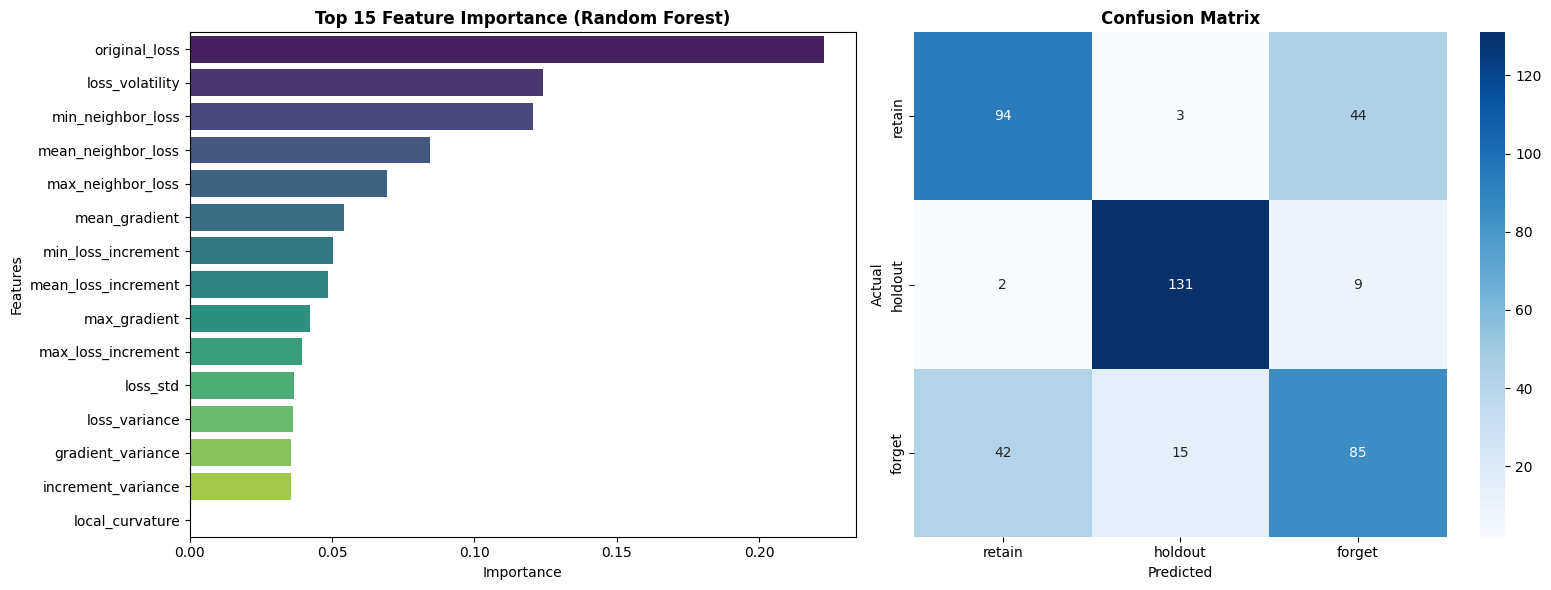

Feature importance statistics:
  Mean importance: 0.066667
  Std importance: 0.052419
  Max importance: 0.222787
  Min importance: 0.000000
  50.0% of importance comes from top 4 features
  70.0% of importance comes from top 7 features
  80.0% of importance comes from top 9 features
  90.0% of importance comes from top 12 features
  95.0% of importance comes from top 13 features


In [34]:
# Visualize feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance plot
top_features = feature_importance_df.head(15)
sns.barplot(data=top_features, y='feature', x='importance', ax=ax1, palette='viridis')
ax1.set_title('Top 15 Feature Importance (Random Forest)', fontweight='bold')
ax1.set_xlabel('Importance')
ax1.set_ylabel('Features')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=class_names, yticklabels=class_names)
ax2.set_title('Confusion Matrix', fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Feature importance statistics
print(f"Feature importance statistics:")
print(f"  Mean importance: {feature_importance.mean():.6f}")
print(f"  Std importance: {feature_importance.std():.6f}")
print(f"  Max importance: {feature_importance.max():.6f}")
print(f"  Min importance: {feature_importance.min():.6f}")

# Check how many features contribute to most of the importance
cumulative_importance = np.cumsum(np.sort(feature_importance)[::-1])
for threshold in [0.5, 0.7, 0.8, 0.9, 0.95]:
    n_features = np.argmax(cumulative_importance >= threshold) + 1
    print(f"  {threshold*100}% of importance comes from top {n_features} features")

# 2. Feature Ablation Study

Now let's systematically remove features and analyze the impact on model performance. This helps us understand:
- Which features are truly necessary
- How robust the model is to feature removal
- Whether we can simplify the model without losing performance

We'll provide flexibility to remove:
1. **Bottom k features** (least important)
2. **Top k features** (most important) 
3. **Custom feature selection** (user-specified features)

In [35]:
# Feature Ablation Study Functions
# All functions are now imported from explore_RF_ILL module:
# - remove_features_and_evaluate()
# - ablation_study_bottom_k()  
# - ablation_study_top_k()

print("Feature ablation functions imported successfully from explore_RF_ILL module!")

Feature ablation functions imported successfully from explore_RF_ILL module!


In [36]:
# Configure ablation study parameters
DEFAULT_K_VALUES = [1, 2, 3, 5, 7, 10]  # Default k values for ablation study

# User configuration section
print("=== FEATURE ABLATION CONFIGURATION ===")
print("Choose ablation strategy:")
print("1. Remove bottom k features (least important)")
print("2. Remove top k features (most important)") 
print("3. Custom feature removal")
print("4. Run all strategies")

# For demo, we'll run all strategies
ablation_strategy = 4

# Configure k values (user can modify these)
k_values_bottom = DEFAULT_K_VALUES  # Remove bottom k features
k_values_top = [1, 2, 3, 5]  # Remove top k features (be careful not to remove too many important ones)

print(f"Running ablation with strategy: {ablation_strategy}")
print(f"Bottom k values: {k_values_bottom}")
print(f"Top k values: {k_values_top}")

# Store baseline performance for comparison
baseline_performance = {
    'cv_mean': cv_scores.mean(),
    'cv_std': cv_scores.std(),
    'test_accuracy': test_accuracy,
    'n_features': len(features_labels)
}

print(f"Baseline performance: {baseline_performance['cv_mean']:.4f} ± {baseline_performance['cv_std']:.4f}")
print(f"Total features available: {len(features_labels)}")

# Run ablation studies
ablation_results = {}

if ablation_strategy in [1, 4]:
    print("\n" + "="*50)
    print("REMOVING BOTTOM K FEATURES (LEAST IMPORTANT)")
    print("="*50)
    bottom_results = rf_ill.ablation_study_bottom_k(
        k_values_bottom, feature_importance_df, X_train, X_test, y_train, y_test, features_labels, class_names
    )
    ablation_results.update(bottom_results)

if ablation_strategy in [2, 4]:
    print("\n" + "="*50)
    print("REMOVING TOP K FEATURES (MOST IMPORTANT)")
    print("="*50)
    top_results = rf_ill.ablation_study_top_k(
        k_values_top, feature_importance_df, X_train, X_test, y_train, y_test, features_labels, class_names
    )
    ablation_results.update(top_results)

=== FEATURE ABLATION CONFIGURATION ===
Choose ablation strategy:
1. Remove bottom k features (least important)
2. Remove top k features (most important)
3. Custom feature removal
4. Run all strategies
Running ablation with strategy: 4
Bottom k values: [1, 2, 3, 5, 7, 10]
Top k values: [1, 2, 3, 5]
Baseline performance: 0.7477 ± 0.0227
Total features available: 15

REMOVING BOTTOM K FEATURES (LEAST IMPORTANT)
Running ablation study: removing bottom k features...


  Removed bottom 1 features: CV Accuracy = 0.7437 ± 0.0226
  Removed bottom 2 features: CV Accuracy = 0.7437 ± 0.0270
  Removed bottom 2 features: CV Accuracy = 0.7437 ± 0.0270
  Removed bottom 3 features: CV Accuracy = 0.7528 ± 0.0286
  Removed bottom 3 features: CV Accuracy = 0.7528 ± 0.0286
  Removed bottom 5 features: CV Accuracy = 0.7548 ± 0.0211
  Removed bottom 5 features: CV Accuracy = 0.7548 ± 0.0211
  Removed bottom 7 features: CV Accuracy = 0.7608 ± 0.0296
  Removed bottom 7 features: CV Accuracy = 0.7608 ± 0.0296
  Removed bottom 10 features: CV Accuracy = 0.7447 ± 0.0317

REMOVING TOP K FEATURES (MOST IMPORTANT)
Running ablation study: removing top k features...
  Removed bottom 10 features: CV Accuracy = 0.7447 ± 0.0317

REMOVING TOP K FEATURES (MOST IMPORTANT)
Running ablation study: removing top k features...
  Removed top 1 features: CV Accuracy = 0.7457 ± 0.0291
  Removed top 1 features: CV Accuracy = 0.7457 ± 0.0291
  Removed top 2 features: CV Accuracy = 0.7518 ± 0.

In [37]:
# Custom feature removal (user can specify which features to remove)
if ablation_strategy in [3, 4]:
    print("\n" + "="*50)
    print("CUSTOM FEATURE REMOVAL")
    print("="*50)
    
    # Example: Remove specific feature categories
    # Users can modify this list based on their interests
    custom_removal_sets = {
        'remove_embeddings': [f for f in features_labels if 'embedding' in f.lower()],
        'remove_loss_features': ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss'],
        'remove_variance_features': ['loss_variance', 'loss_std', 'increment_variance'],
        'remove_gradient_features': ['mean_gradient', 'max_gradient', 'gradient_variance'],
        'remove_landscape_features': ['loss_volatility', 'local_curvature']
    }
    
    print("Testing custom feature removal sets:")
    for removal_name, features_to_remove in custom_removal_sets.items():
        # Only remove features that actually exist
        existing_features_to_remove = [f for f in features_to_remove if f in features_labels]
        
        if existing_features_to_remove:
            print(f"\n{removal_name}: removing {existing_features_to_remove}")
            result = rf_ill.remove_features_and_evaluate(
                X_train, X_test, y_train, y_test, existing_features_to_remove, features_labels, class_names
            )
            ablation_results[removal_name] = result
            print(f"  CV Accuracy = {result['cv_mean']:.4f} ± {result['cv_std']:.4f}")
        else:
            print(f"\n{removal_name}: No matching features found")

# Visualize ablation results
print("\n" + "="*60)
print("ABLATION STUDY SUMMARY")
print("="*60)

# Create summary dataframe
summary_data = []
summary_data.append({
    'experiment': 'baseline',
    'features_removed': 0,
    'features_kept': len(features_labels),
    'cv_mean': baseline_performance['cv_mean'],
    'cv_std': baseline_performance['cv_std'],
    'test_accuracy': baseline_performance['test_accuracy']
})

for exp_name, result in ablation_results.items():
    summary_data.append({
        'experiment': exp_name,
        'features_removed': result['n_features_removed'],
        'features_kept': result['n_features_kept'],
        'cv_mean': result['cv_mean'],
        'cv_std': result['cv_std'],
        'test_accuracy': result['test_accuracy']
    })

summary_df = pd.DataFrame(summary_data)
summary_df['performance_drop'] = baseline_performance['cv_mean'] - summary_df['cv_mean']

print("\nAblation Study Results:")
print(summary_df.round(4))

# Find best performing reduced models
print("\nBest performing models after feature removal:")
reduced_models = summary_df[summary_df['experiment'] != 'baseline'].copy()
best_reduced = reduced_models.loc[reduced_models['cv_mean'].idxmax()]
print(f"Best reduced model: {best_reduced['experiment']}")
print(f"  CV Accuracy: {best_reduced['cv_mean']:.4f} ± {best_reduced['cv_std']:.4f}")
print(f"  Features kept: {best_reduced['features_kept']}")
print(f"  Performance drop: {best_reduced['performance_drop']:.4f}")

# Find models with minimal performance loss
minimal_loss_threshold = 0.01  # 1% accuracy drop
minimal_loss_models = reduced_models[reduced_models['performance_drop'] <= minimal_loss_threshold]
if len(minimal_loss_models) > 0:
    print(f"\nModels with <{minimal_loss_threshold*100}% performance drop:")
    for _, model in minimal_loss_models.iterrows():
        print(f"  {model['experiment']}: {model['features_kept']} features, drop = {model['performance_drop']:.4f}")
else:
    print(f"\nNo models found with <{minimal_loss_threshold*100}% performance drop")


CUSTOM FEATURE REMOVAL
Testing custom feature removal sets:

remove_embeddings: No matching features found

remove_loss_features: removing ['original_loss', 'mean_neighbor_loss', 'max_neighbor_loss', 'min_neighbor_loss']


  CV Accuracy = 0.6801 ± 0.0327

remove_variance_features: removing ['loss_variance', 'loss_std', 'increment_variance']
  CV Accuracy = 0.7437 ± 0.0375

remove_gradient_features: removing ['mean_gradient', 'max_gradient', 'gradient_variance']
  CV Accuracy = 0.7437 ± 0.0375

remove_gradient_features: removing ['mean_gradient', 'max_gradient', 'gradient_variance']
  CV Accuracy = 0.7538 ± 0.0304

remove_landscape_features: removing ['loss_volatility', 'local_curvature']
  CV Accuracy = 0.7538 ± 0.0304

remove_landscape_features: removing ['loss_volatility', 'local_curvature']
  CV Accuracy = 0.7558 ± 0.0300

ABLATION STUDY SUMMARY

Ablation Study Results:
                   experiment  features_removed  features_kept  cv_mean  \
0                    baseline                 0             15   0.7477   
1             remove_bottom_1                 1             14   0.7437   
2             remove_bottom_2                 2             13   0.7437   
3             remove_bottom_3        

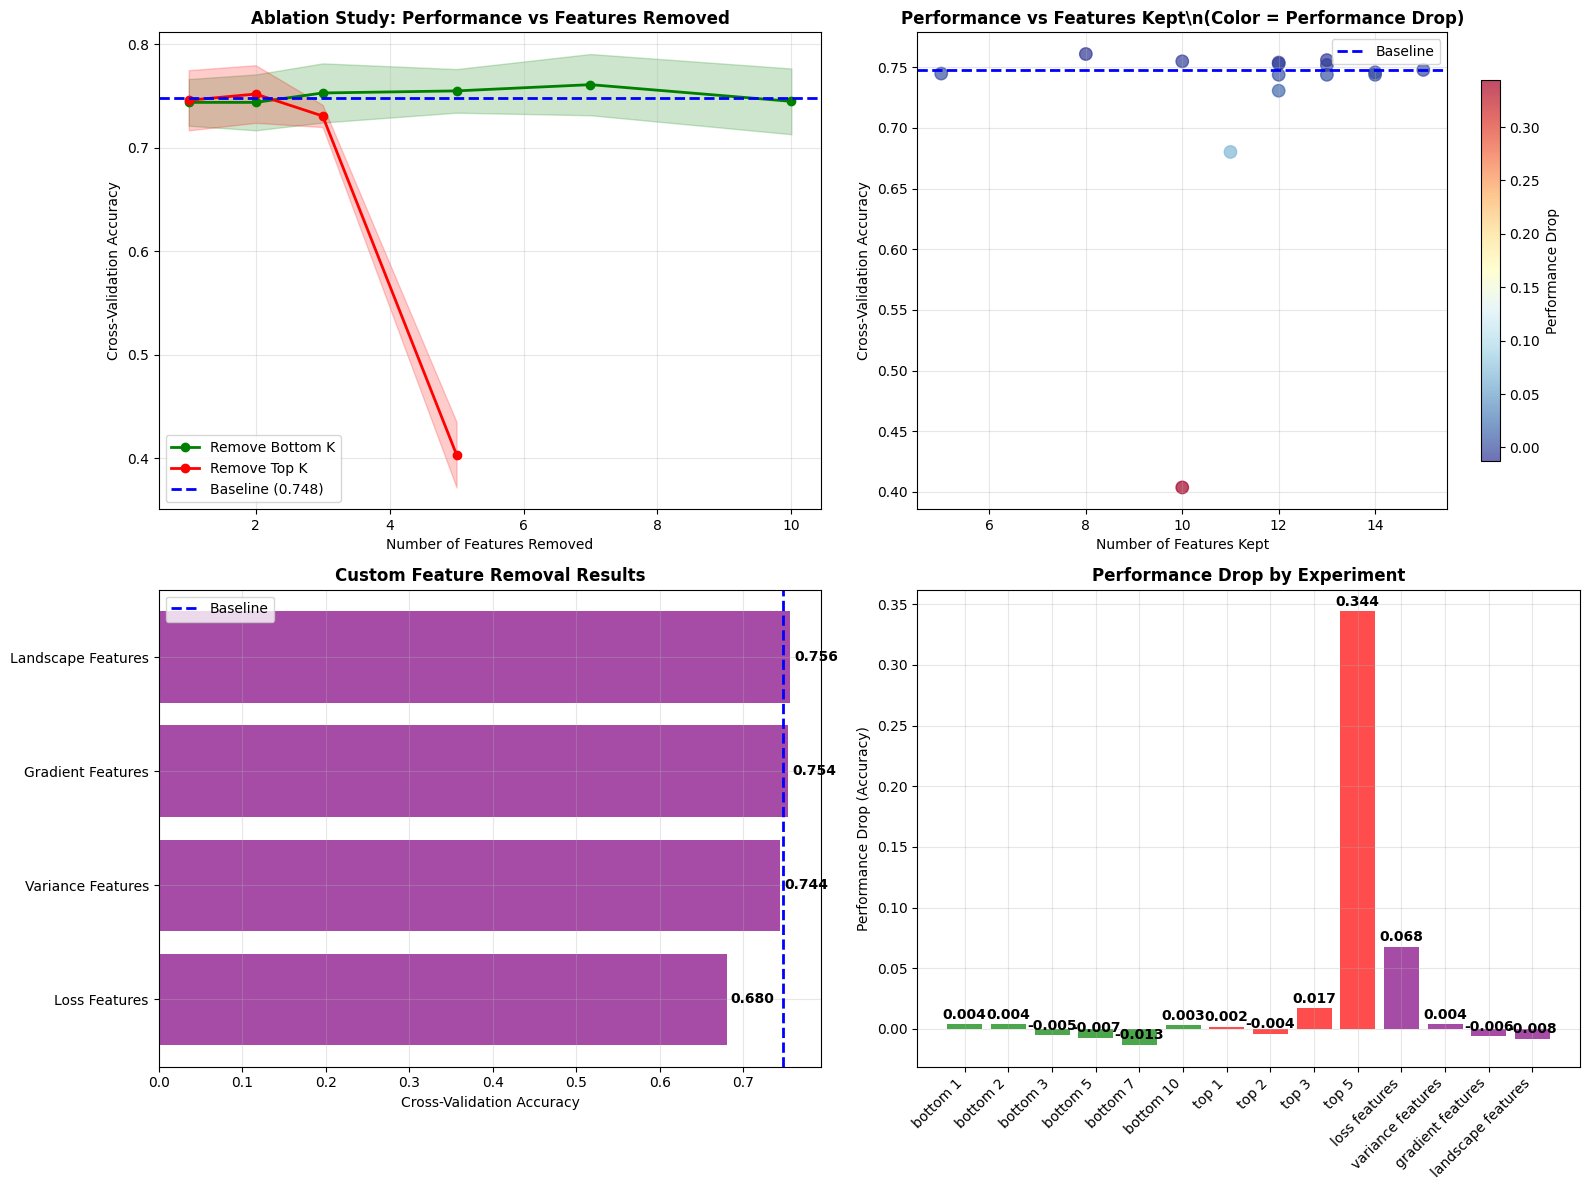

\nAblation study visualization complete!


In [38]:
# Plot ablation study results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Performance vs Number of Features Removed
bottom_experiments = [exp for exp in summary_df['experiment'] if 'remove_bottom' in exp]
top_experiments = [exp for exp in summary_df['experiment'] if 'remove_top' in exp]

if bottom_experiments:
    bottom_data = summary_df[summary_df['experiment'].isin(bottom_experiments)]
    ax1.plot(bottom_data['features_removed'], bottom_data['cv_mean'], 
             'o-', label='Remove Bottom K', color='green', linewidth=2, markersize=6)
    ax1.fill_between(bottom_data['features_removed'], 
                     bottom_data['cv_mean'] - bottom_data['cv_std'],
                     bottom_data['cv_mean'] + bottom_data['cv_std'],
                     alpha=0.2, color='green')

if top_experiments:
    top_data = summary_df[summary_df['experiment'].isin(top_experiments)]
    ax1.plot(top_data['features_removed'], top_data['cv_mean'], 
             'o-', label='Remove Top K', color='red', linewidth=2, markersize=6)
    ax1.fill_between(top_data['features_removed'], 
                     top_data['cv_mean'] - top_data['cv_std'],
                     top_data['cv_mean'] + top_data['cv_std'],
                     alpha=0.2, color='red')

# Add baseline line
ax1.axhline(y=baseline_performance['cv_mean'], color='blue', linestyle='--', 
            label=f'Baseline ({baseline_performance["cv_mean"]:.3f})', linewidth=2)

ax1.set_xlabel('Number of Features Removed')
ax1.set_ylabel('Cross-Validation Accuracy')
ax1.set_title('Ablation Study: Performance vs Features Removed', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Performance vs Number of Features Kept
ax2.scatter(summary_df['features_kept'], summary_df['cv_mean'], 
           s=80, c=summary_df['performance_drop'], cmap='RdYlBu_r', alpha=0.7)
ax2.axhline(y=baseline_performance['cv_mean'], color='blue', linestyle='--', 
            label=f'Baseline', linewidth=2)
ax2.set_xlabel('Number of Features Kept')
ax2.set_ylabel('Cross-Validation Accuracy')
ax2.set_title('Performance vs Features Kept\\n(Color = Performance Drop)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add colorbar for performance drop
cbar = plt.colorbar(ax2.collections[0], ax=ax2, shrink=0.8)
cbar.set_label('Performance Drop')

# 3. Custom experiments comparison
custom_experiments = [exp for exp in summary_df['experiment'] 
                     if exp not in ['baseline'] + bottom_experiments + top_experiments]
if custom_experiments:
    custom_data = summary_df[summary_df['experiment'].isin(custom_experiments)]
    y_pos = np.arange(len(custom_data))
    bars = ax3.barh(y_pos, custom_data['cv_mean'], color='purple', alpha=0.7)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels([exp.replace('remove_', '').replace('_', ' ').title() 
                        for exp in custom_data['experiment']])
    ax3.axvline(x=baseline_performance['cv_mean'], color='blue', linestyle='--', 
                label=f'Baseline', linewidth=2)
    ax3.set_xlabel('Cross-Validation Accuracy')
    ax3.set_title('Custom Feature Removal Results', fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, acc) in enumerate(zip(bars, custom_data['cv_mean'])):
        ax3.text(acc + 0.005, bar.get_y() + bar.get_height()/2, 
                f'{acc:.3f}', va='center', fontweight='bold')
else:
    ax3.text(0.5, 0.5, 'No custom experiments run', 
             transform=ax3.transAxes, ha='center', va='center', fontsize=12)
    ax3.set_title('Custom Feature Removal Results', fontweight='bold')

# 4. Performance drop analysis
non_baseline = summary_df[summary_df['experiment'] != 'baseline']
colors = ['green' if 'bottom' in exp else 'red' if 'top' in exp else 'purple' 
          for exp in non_baseline['experiment']]

bars = ax4.bar(range(len(non_baseline)), non_baseline['performance_drop'], 
               color=colors, alpha=0.7)
ax4.set_xticks(range(len(non_baseline)))
ax4.set_xticklabels([exp.replace('remove_', '').replace('_', ' ') 
                    for exp in non_baseline['experiment']], rotation=45, ha='right')
ax4.set_ylabel('Performance Drop (Accuracy)')
ax4.set_title('Performance Drop by Experiment', fontweight='bold')
ax4.grid(True, alpha=0.3)

# Add value labels on bars
for bar, drop in zip(bars, non_baseline['performance_drop']):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{drop:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\\nAblation study visualization complete!")

# 3. Tree Surrogate Models

Tree surrogate models are interpretable decision trees trained to approximate the behavior of more complex models (like Random Forest). They help us understand:

- **Decision rules**: Simple if-then rules the RF seems to be following
- **Feature interactions**: How features combine to make decisions
- **Model simplification**: A single tree that captures most of the RF's behavior

We'll train decision trees to mimic the Random Forest predictions and analyze the resulting rules.

In [39]:
# Train Tree Surrogate Models

def train_tree_surrogate(rf_model, X_train, X_test, y_train, y_test, feature_names, max_depth=None):
    """
    Train a decision tree to mimic the Random Forest's behavior
    """
    # Get Random Forest predictions on training data (this is what we want to mimic)
    rf_train_predictions = rf_model.predict(X_train)
    rf_test_predictions = rf_model.predict(X_test)
    
    # Train decision tree to predict what the RF predicts
    surrogate_tree = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )
    
    surrogate_tree.fit(X_train, rf_train_predictions)
    
    # Evaluate how well the tree mimics the RF
    tree_train_predictions = surrogate_tree.predict(X_train)
    tree_test_predictions = surrogate_tree.predict(X_test)
    
    # Fidelity: How well does the tree match the RF's predictions?
    train_fidelity = accuracy_score(rf_train_predictions, tree_train_predictions)
    test_fidelity = accuracy_score(rf_test_predictions, tree_test_predictions)
    
    # Accuracy: How well does the tree perform on the actual labels?
    train_accuracy = accuracy_score(y_train, tree_train_predictions)
    test_accuracy = accuracy_score(y_test, tree_test_predictions)
    
    return {
        'model': surrogate_tree,
        'train_fidelity': train_fidelity,
        'test_fidelity': test_fidelity,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'max_depth': max_depth,
        'n_leaves': surrogate_tree.get_n_leaves(),
        'tree_depth': surrogate_tree.get_depth()
    }

print("Training Tree Surrogate Models with different complexities...")

# Train surrogate trees with different max depths
max_depths = [3, 5, 7, 10, 15, None]
surrogate_results = {}

for max_depth in max_depths:
    print(f"\\nTraining surrogate tree with max_depth={max_depth}...")
    result = train_tree_surrogate(rf_baseline, X_train, X_test, y_train, y_test, features_labels, max_depth)
    
    depth_key = f"depth_{max_depth}" if max_depth is not None else "depth_unlimited"
    surrogate_results[depth_key] = result
    
    print(f"  Tree depth: {result['tree_depth']}, Leaves: {result['n_leaves']}")
    print(f"  Fidelity (mimics RF): Train={result['train_fidelity']:.4f}, Test={result['test_fidelity']:.4f}")
    print(f"  Accuracy (actual labels): Train={result['train_accuracy']:.4f}, Test={result['test_accuracy']:.4f}")

# Find the best surrogate tree (balance between fidelity and simplicity)
print("\\n" + "="*60)
print("SURROGATE TREE SUMMARY")
print("="*60)

# Create summary dataframe
surrogate_summary = []
for name, result in surrogate_results.items():
    surrogate_summary.append({
        'model': name,
        'max_depth': result['max_depth'],
        'actual_depth': result['tree_depth'],
        'n_leaves': result['n_leaves'],
        'test_fidelity': result['test_fidelity'],
        'test_accuracy': result['test_accuracy'],
        'fidelity_accuracy_diff': abs(result['test_fidelity'] - result['test_accuracy'])
    })

surrogate_df = pd.DataFrame(surrogate_summary)
print(surrogate_df.round(4))

# Select best surrogate (high fidelity, reasonable complexity)
# Prefer trees with >80% fidelity and reasonable depth
good_surrogates = surrogate_df[surrogate_df['test_fidelity'] > 0.8]
if len(good_surrogates) > 0:
    # Among good surrogates, pick the simplest (fewest leaves)
    best_surrogate_idx = good_surrogates['n_leaves'].idxmin()
    best_surrogate_name = surrogate_df.loc[best_surrogate_idx, 'model']
else:
    # If no good surrogates, pick the one with highest fidelity
    best_surrogate_idx = surrogate_df['test_fidelity'].idxmax()
    best_surrogate_name = surrogate_df.loc[best_surrogate_idx, 'model']

best_surrogate = surrogate_results[best_surrogate_name]
print(f"\\nBest surrogate model: {best_surrogate_name}")
print(f"  Depth: {best_surrogate['tree_depth']}, Leaves: {best_surrogate['n_leaves']}")
print(f"  Test Fidelity: {best_surrogate['test_fidelity']:.4f}")
print(f"  Test Accuracy: {best_surrogate['test_accuracy']:.4f}")

Training Tree Surrogate Models with different complexities...
\nTraining surrogate tree with max_depth=3...
  Tree depth: 3, Leaves: 8
  Fidelity (mimics RF): Train=0.7770, Test=0.8635
  Accuracy (actual labels): Train=0.7770, Test=0.7624
\nTraining surrogate tree with max_depth=5...
  Tree depth: 5, Leaves: 25
  Fidelity (mimics RF): Train=0.8153, Test=0.8612
  Accuracy (actual labels): Train=0.8153, Test=0.7482
\nTraining surrogate tree with max_depth=7...
  Tree depth: 7, Leaves: 49
  Fidelity (mimics RF): Train=0.8456, Test=0.8235
  Accuracy (actual labels): Train=0.8456, Test=0.6988
\nTraining surrogate tree with max_depth=10...
  Tree depth: 5, Leaves: 25
  Fidelity (mimics RF): Train=0.8153, Test=0.8612
  Accuracy (actual labels): Train=0.8153, Test=0.7482
\nTraining surrogate tree with max_depth=7...
  Tree depth: 7, Leaves: 49
  Fidelity (mimics RF): Train=0.8456, Test=0.8235
  Accuracy (actual labels): Train=0.8456, Test=0.6988
\nTraining surrogate tree with max_depth=10...
 

  Tree depth: 13, Leaves: 94
  Fidelity (mimics RF): Train=0.8890, Test=0.7765
  Accuracy (actual labels): Train=0.8890, Test=0.6682
\nTraining surrogate tree with max_depth=None...
  Tree depth: 13, Leaves: 94
  Fidelity (mimics RF): Train=0.8890, Test=0.7765
  Accuracy (actual labels): Train=0.8890, Test=0.6682
\n============================================================
SURROGATE TREE SUMMARY
             model  max_depth  actual_depth  n_leaves  test_fidelity  \
0          depth_3        3.0             3         8         0.8635   
1          depth_5        5.0             5        25         0.8612   
2          depth_7        7.0             7        49         0.8235   
3         depth_10       10.0            10        84         0.7694   
4         depth_15       15.0            13        94         0.7765   
5  depth_unlimited        NaN            13        94         0.7765   

   test_accuracy  fidelity_accuracy_diff  
0         0.7624                  0.1012  
1       

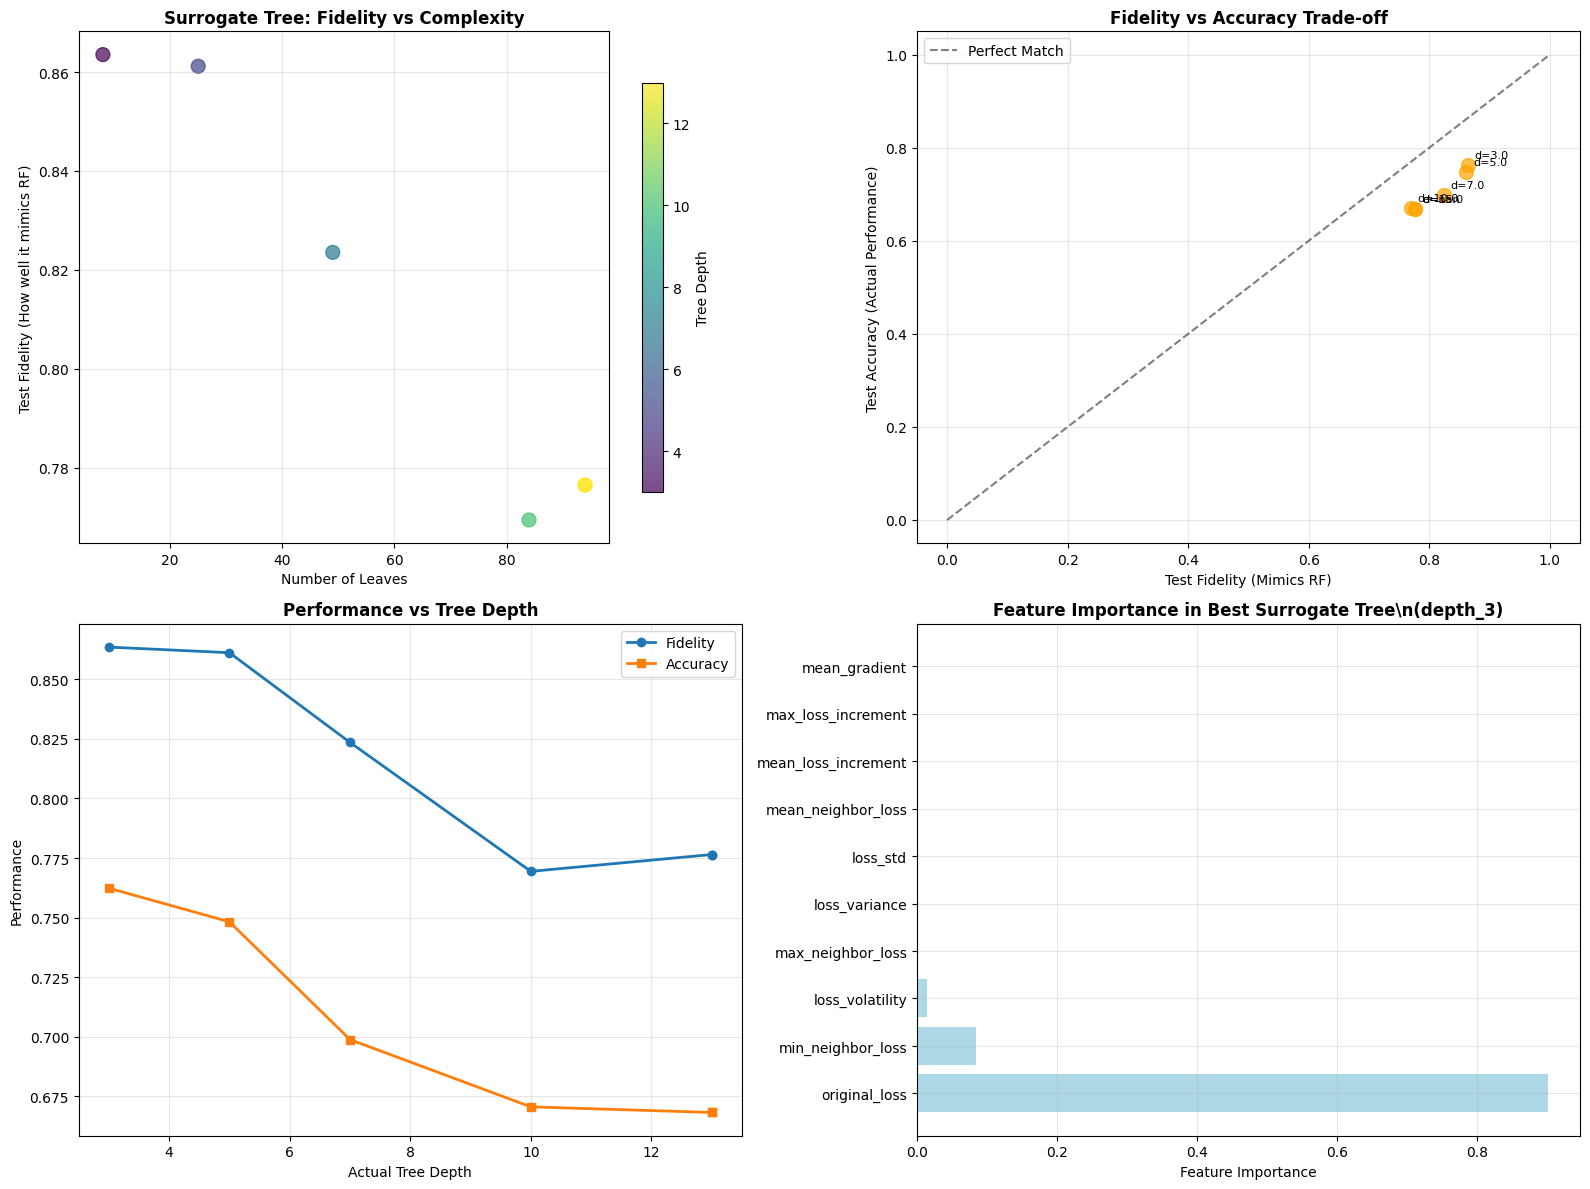

\n================================================================================
DECISION RULES FROM BEST SURROGATE TREE
Tree Structure (depth_3):
Depth: 3, Leaves: 8
Fidelity: 0.8635, Accuracy: 0.7624
\nDecision Rules:
|--- original_loss <= 0.23
|   |--- original_loss <= -0.97
|   |   |--- loss_volatility <= 0.13
|   |   |   |--- weights: [15.00, 0.00, 11.00] class: retain
|   |   |--- loss_volatility >  0.13
|   |   |   |--- weights: [176.00, 0.00, 18.00] class: retain
|   |--- original_loss >  -0.97
|   |   |--- original_loss <= -0.68
|   |   |   |--- weights: [65.00, 0.00, 59.00] class: retain
|   |   |--- original_loss >  -0.68
|   |   |   |--- weights: [60.00, 4.00, 166.00] class: forget
|--- original_loss >  0.23
|   |--- min_neighbor_loss <= -0.19
|   |   |--- original_loss <= 0.50
|   |   |   |--- weights: [5.00, 2.00, 10.00] class: forget
|   |   |--- original_loss >  0.50
|   |   |   |--- weights: [0.00, 0.00, 14.00] class: forget
|   |--- min_neighbor_loss >  -0.19
|   | 

In [40]:
# Visualize surrogate tree performance and extract decision rules

# Plot surrogate tree performance
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Fidelity vs Complexity
ax1.scatter(surrogate_df['n_leaves'], surrogate_df['test_fidelity'], 
           s=100, c=surrogate_df['actual_depth'], cmap='viridis', alpha=0.7)
ax1.set_xlabel('Number of Leaves')
ax1.set_ylabel('Test Fidelity (How well it mimics RF)')
ax1.set_title('Surrogate Tree: Fidelity vs Complexity', fontweight='bold')
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(ax1.collections[0], ax=ax1, shrink=0.8)
cbar1.set_label('Tree Depth')

# 2. Accuracy vs Fidelity
ax2.scatter(surrogate_df['test_fidelity'], surrogate_df['test_accuracy'], 
           s=100, alpha=0.7, c='orange')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect Match')
ax2.set_xlabel('Test Fidelity (Mimics RF)')
ax2.set_ylabel('Test Accuracy (Actual Performance)')
ax2.set_title('Fidelity vs Accuracy Trade-off', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add annotations for each point
for idx, row in surrogate_df.iterrows():
    ax2.annotate(f"d={row['max_depth']}", 
                (row['test_fidelity'], row['test_accuracy']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

# 3. Tree complexity progression
ax3.plot(surrogate_df['actual_depth'], surrogate_df['test_fidelity'], 
         'o-', label='Fidelity', linewidth=2, markersize=6)
ax3.plot(surrogate_df['actual_depth'], surrogate_df['test_accuracy'], 
         's-', label='Accuracy', linewidth=2, markersize=6)
ax3.set_xlabel('Actual Tree Depth')
ax3.set_ylabel('Performance')
ax3.set_title('Performance vs Tree Depth', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Feature importance in best surrogate tree
best_tree_model = best_surrogate['model']
tree_feature_importance = best_tree_model.feature_importances_
tree_importance_df = pd.DataFrame({
    'feature': features_labels,
    'importance': tree_feature_importance
}).sort_values('importance', ascending=False)

top_tree_features = tree_importance_df.head(10)
ax4.barh(range(len(top_tree_features)), top_tree_features['importance'], color='lightblue')
ax4.set_yticks(range(len(top_tree_features)))
ax4.set_yticklabels(top_tree_features['feature'])
ax4.set_xlabel('Feature Importance')
ax4.set_title(f'Feature Importance in Best Surrogate Tree\\n({best_surrogate_name})', fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Extract and display decision rules from the best surrogate tree
print("\\n" + "="*80)
print("DECISION RULES FROM BEST SURROGATE TREE")
print("="*80)

# Extract text representation of the tree
tree_rules = export_text(best_tree_model, 
                        feature_names=features_labels,
                        class_names=class_names,
                        show_weights=True)

print(f"Tree Structure ({best_surrogate_name}):")
print(f"Depth: {best_surrogate['tree_depth']}, Leaves: {best_surrogate['n_leaves']}")
print(f"Fidelity: {best_surrogate['test_fidelity']:.4f}, Accuracy: {best_surrogate['test_accuracy']:.4f}")
print("\\nDecision Rules:")
print(tree_rules[:2000] + "..." if len(tree_rules) > 2000 else tree_rules)

# Compare RF vs Tree feature importance
print("\\n" + "="*60)
print("FEATURE IMPORTANCE COMPARISON: RF vs SURROGATE TREE")
print("="*60)

# Merge RF and Tree feature importance
importance_comparison = feature_importance_df.merge(
    tree_importance_df, on='feature', suffixes=('_rf', '_tree')
)

print("\\nTop 10 features in Random Forest vs Surrogate Tree:")
top_comparison = importance_comparison.head(10)
print(top_comparison[['feature', 'importance_rf', 'importance_tree']].round(4))

# Calculate correlation between RF and Tree feature importance
importance_correlation = np.corrcoef(importance_comparison['importance_rf'], 
                                   importance_comparison['importance_tree'])[0, 1]
print(f"\\nFeature importance correlation (RF vs Tree): {importance_correlation:.4f}")

if importance_correlation > 0.7:
    print("High correlation - Tree captures similar feature patterns as RF")
elif importance_correlation > 0.4:
    print("Moderate correlation - Tree partially captures RF patterns")
else:
    print("Low correlation - Tree uses different features than RF")

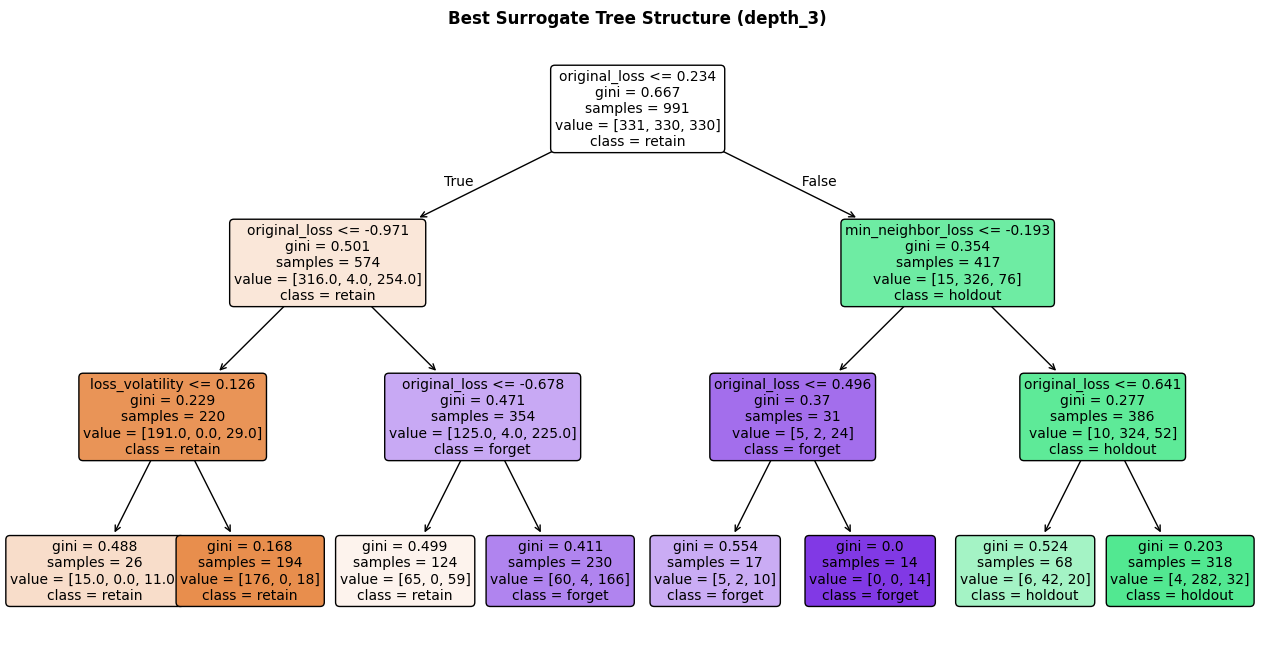

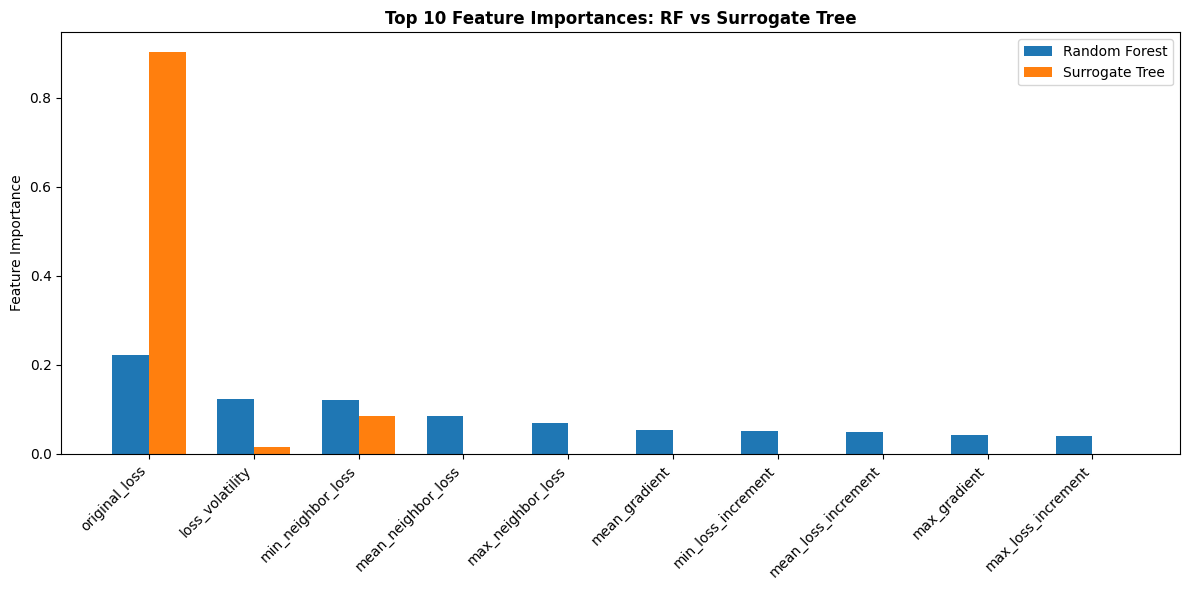

In [41]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))
plot_tree(
    best_tree_model,
    feature_names=features_labels,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3  # adjust if you want to see more/less
)
plt.title(f"Best Surrogate Tree Structure ({best_surrogate_name})", fontweight='bold')
plt.show()

# Bar plot for top 10 features: RF vs Surrogate Tree
top_comparison = importance_comparison.head(10)

x = np.arange(len(top_comparison))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, top_comparison['importance_rf'], width, label='Random Forest')
ax.bar(x + width/2, top_comparison['importance_tree'], width, label='Surrogate Tree')
ax.set_xticks(x)
ax.set_xticklabels(top_comparison['feature'], rotation=45, ha='right')
ax.set_ylabel('Feature Importance')
ax.set_title('Top 10 Feature Importances: RF vs Surrogate Tree', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# 4. Advanced Interpretability Methods

Now we'll apply several advanced interpretability techniques to gain deeper insights into how the Random Forest makes decisions:

## Methods Covered:
1. **Permutation Importance** - Which features hurt performance most when shuffled?
2. **Partial Dependence Plots** - How does each feature affect predictions?
3. **SHAP Analysis** - Feature contributions for individual predictions (if available)
4. **Feature Interactions** - Do features work together or independently?

These methods help us understand not just *which* features are important, but *how* they influence the model's decisions.

## How to Read Permutation Importance and Importance Comparison Plots

### 1. **Permutation Importance with Error Bars**  
- **What is shown?**  
  A horizontal bar chart of the top 15 features ranked by **permutation importance** — how much the model’s accuracy drops when the feature is randomly shuffled.  
- **How to read:**  
  - Longer bars mean the feature is more important for accurate predictions.  
  - Error bars show variability across multiple shuffling repetitions — smaller error bars indicate more stable importance estimates.  
  - Features at the top are most critical to the model’s predictions.

---

### 2. **Random Forest vs Permutation Importance Scatter Plot**  
- **What is shown?**  
  A scatter plot comparing each feature’s **Random Forest (RF) importance** with its **permutation importance**.  
- **How to read:**  
  - Each point is a feature.  
  - The dashed diagonal line represents perfect agreement between the two measures.  
  - Points close to the line mean the two methods agree on the feature’s importance; far-off points show disagreement.  
  - The correlation value in the title quantifies overall agreement.
  - Points below the line: RF rates the feature higher than permutation does.  
  - Many with low-y → Likely redundant or correlated; shuffling has little effect.  
  - High x + low y → RF greatly overestimates importance.  
  - High x + high y → Truly important, but RF still inflates its importance.
  - Points above the line:** Permutation finds more predictive power than RF’s metric suggests.

---

### 3. **Three Importance Measures Bar Chart**  
- **What is shown?**  
  A grouped bar chart for the top 10 features, comparing:  
  1. **Random Forest importance** (blue)  
  2. **Permutation importance** (orange)  
  3. **Tree Surrogate importance** (green)  
- **How to read:**  
  - Height of each bar shows how strongly each method ranks the feature.  
  - If one method rates a feature high while others rate it low, it may indicate method-specific bias or sensitivity.  
  - Features consistently high across all methods are robustly important.

---

### 4. **Importance Disagreement Scatter Plot**  
- **What is shown?**  
  Features with the largest **relative disagreement** between importance measures.  
  - **x-axis:** Maximum importance value (from any of the three methods).  
  - **y-axis:** Relative disagreement = (standard deviation of the three importance values) ÷ (maximum importance).  
- **How to read:**  
  - High **y** values mean the methods disagree strongly on how important the feature is.  
  - Features in the upper-right are both important and controversial between methods.  
  - Annotated labels highlight the top disagreement cases.
  - Most points on the left (low x): These features have low maximum importance across RF and permutation measures — they are generally less important overall.  
 
- *Tip* Focus more on features with higher importance (right side) for meaningful disagreement analysis.

Computing Permutation Importance...
This measures how much performance drops when each feature is randomly shuffled



Top 10 Features by Permutation Importance:
               feature  importance_mean  importance_std
0        original_loss           0.1696          0.0098
3    min_neighbor_loss           0.0287          0.0100
7   max_loss_increment           0.0061          0.0046
10        max_gradient           0.0040          0.0063
12     loss_volatility           0.0026          0.0101
1   mean_neighbor_loss           0.0012          0.0050
13     local_curvature           0.0000          0.0000
5             loss_std          -0.0021          0.0036
4        loss_variance          -0.0028          0.0054
2    max_neighbor_loss          -0.0033          0.0060

Importance Measure Correlations:
  RF vs Permutation: 0.8465
  RF vs Tree: 0.8293
  Permutation vs Tree: 0.9922


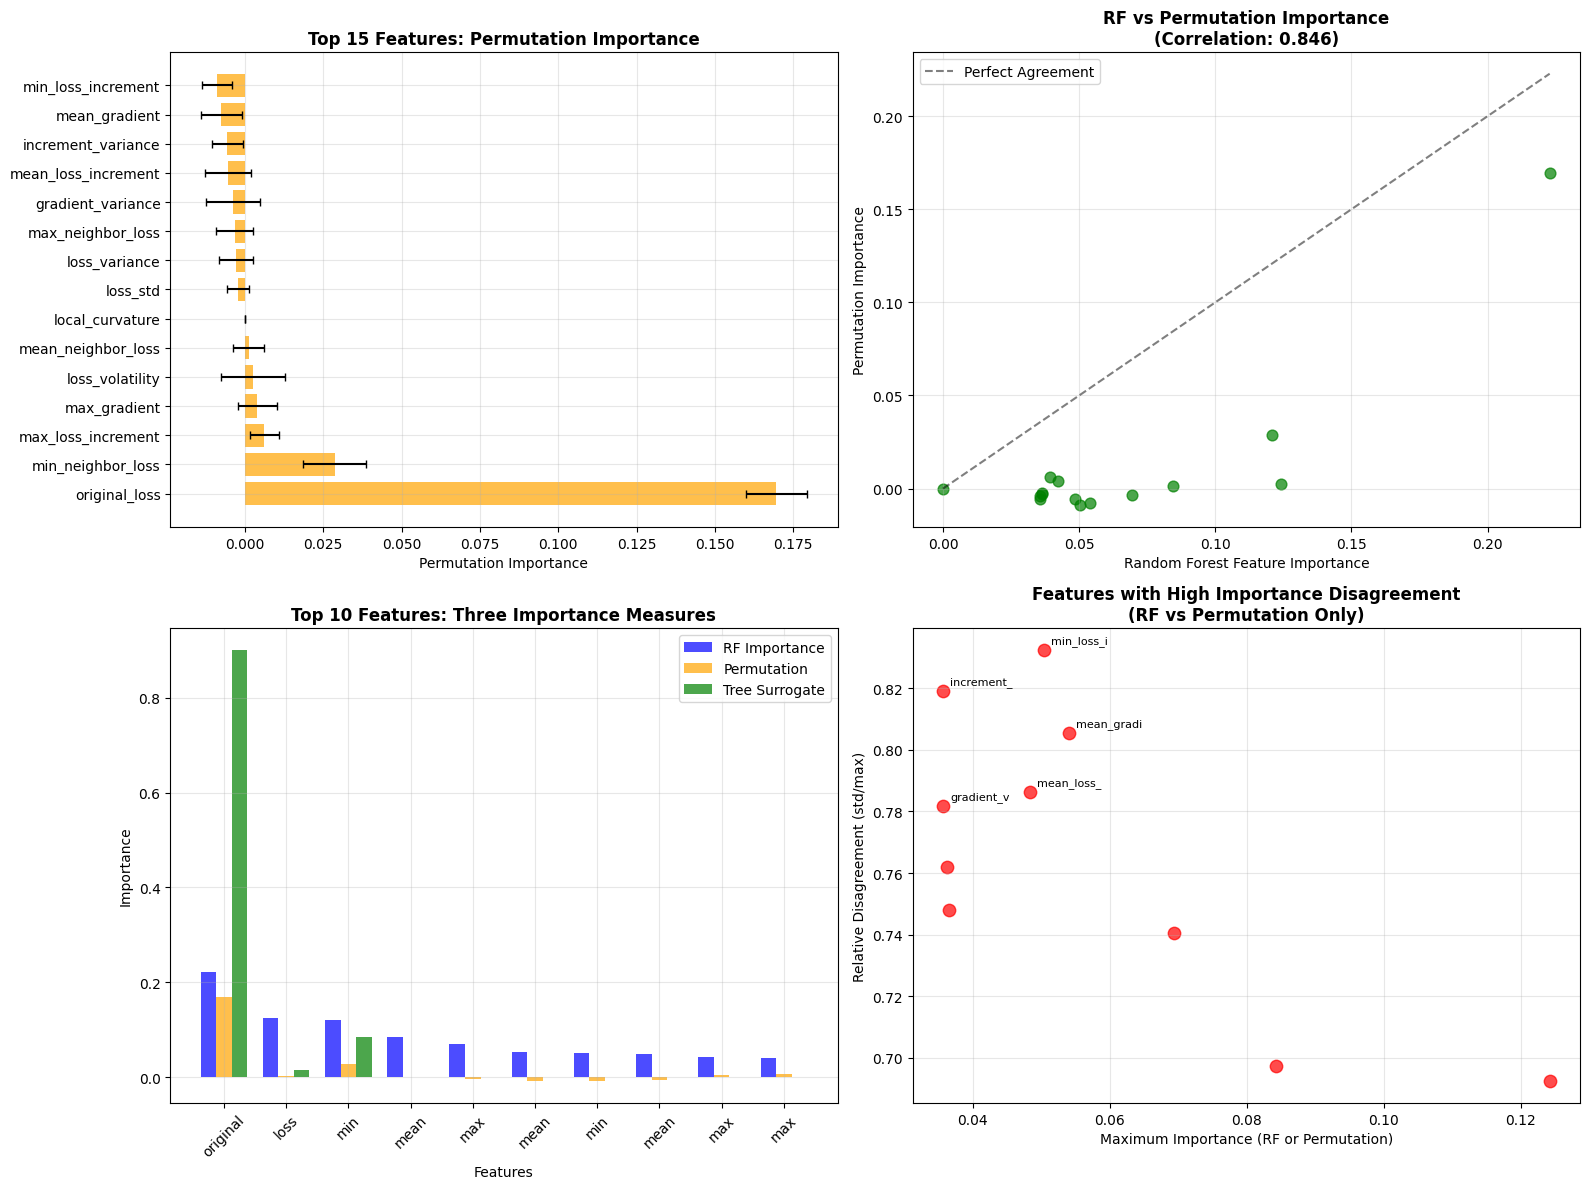


Features with highest disagreement between RF and permutation importance:
                feature  importance_rf  importance_perm  disagreement_2way
6    min_loss_increment         0.0504          -0.0089             0.8324
13   increment_variance         0.0357          -0.0056             0.8191
5         mean_gradient         0.0541          -0.0075             0.8056
7   mean_loss_increment         0.0484          -0.0054             0.7862
12    gradient_variance         0.0357          -0.0038             0.7816


In [42]:
# 4.1 Permutation Importance Analysis

# Use imported function for permutation importance analysis
perm_importance_df, perm_importance = rf_ill.run_permutation_importance_analysis(
    rf_baseline, X_test, y_test, features_labels
)

print("\nTop 10 Features by Permutation Importance:")
print(perm_importance_df.head(10).round(4))

# Compare different importance measures
importance_comparison_full = feature_importance_df.merge(
    perm_importance_df[['feature', 'importance_mean']], on='feature'
).merge(
    tree_importance_df[['feature', 'importance']], on='feature', suffixes=('', '_tree')
)

# Rename columns for clarity
importance_comparison_full = importance_comparison_full.rename(columns={
    'importance': 'importance_rf',
    'importance_mean': 'importance_perm',
    'importance_tree': 'importance_tree'
})

# If 'importance_tree' is not present, it means the merge kept it as 'importance_tree' already
if 'importance_tree' not in importance_comparison_full.columns and 'importance' in importance_comparison_full.columns:
    importance_comparison_full = importance_comparison_full.rename(columns={'importance': 'importance_tree'})

# Now you can safely use the columns
rf_perm_corr = np.corrcoef(importance_comparison_full['importance_rf'], 
                          importance_comparison_full['importance_perm'])[0, 1]
rf_tree_corr = np.corrcoef(importance_comparison_full['importance_rf'], 
                          importance_comparison_full['importance_tree'])[0, 1]
perm_tree_corr = np.corrcoef(importance_comparison_full['importance_perm'], 
                           importance_comparison_full['importance_tree'])[0, 1]

print(f"\nImportance Measure Correlations:")
print(f"  RF vs Permutation: {rf_perm_corr:.4f}")
print(f"  RF vs Tree: {rf_tree_corr:.4f}")
print(f"  Permutation vs Tree: {perm_tree_corr:.4f}")

# Visualize importance comparisons
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Permutation importance with error bars
top_perm_features = perm_importance_df.head(15)
y_pos = range(len(top_perm_features))
ax1.barh(y_pos, top_perm_features['importance_mean'], 
         xerr=top_perm_features['importance_std'], 
         color='orange', alpha=0.7, capsize=3)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_perm_features['feature'])
ax1.set_xlabel('Permutation Importance')
ax1.set_title('Top 15 Features: Permutation Importance', fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. RF importance vs Permutation importance
ax2.scatter(importance_comparison_full['importance_rf'], 
           importance_comparison_full['importance_perm'], 
           alpha=0.7, s=60, c='green')
ax2.set_xlabel('Random Forest Feature Importance')
ax2.set_ylabel('Permutation Importance')
ax2.set_title(f'RF vs Permutation Importance\n(Correlation: {rf_perm_corr:.3f})', fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add diagonal line
max_val = max(importance_comparison_full['importance_rf'].max(), 
              importance_comparison_full['importance_perm'].max())
ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Perfect Agreement')
ax2.legend()

# 3. Three-way importance comparison for top features
top_features_multi = importance_comparison_full.head(10)
x = np.arange(len(top_features_multi))
width = 0.25

ax3.bar(x - width, top_features_multi['importance_rf'], width, 
        label='RF Importance', color='blue', alpha=0.7)
ax3.bar(x, top_features_multi['importance_perm'], width, 
        label='Permutation', color='orange', alpha=0.7)
ax3.bar(x + width, top_features_multi['importance_tree'], width, 
        label='Tree Surrogate', color='green', alpha=0.7)

ax3.set_xlabel('Features')
ax3.set_ylabel('Importance')
ax3.set_title('Top 10 Features: Three Importance Measures', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f.split('_')[0] for f in top_features_multi['feature']], rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Importance disagreement analysis (RF vs Permutation only)
importance_comparison_full['max_importance_2way'] = importance_comparison_full[['importance_rf', 'importance_perm']].max(axis=1)
importance_comparison_full['importance_std_2way'] = importance_comparison_full[['importance_rf', 'importance_perm']].std(axis=1)
importance_comparison_full['disagreement_2way'] = (
    importance_comparison_full['importance_std_2way'] /
    importance_comparison_full['max_importance_2way']
)

# Features with high disagreement between RF and permutation importance
high_disagreement_2way = importance_comparison_full.nlargest(10, 'disagreement_2way')

ax4.scatter(
    high_disagreement_2way['max_importance_2way'],
    high_disagreement_2way['disagreement_2way'],
    s=80, alpha=0.7, c='red'
)
ax4.set_xlabel('Maximum Importance (RF or Permutation)')
ax4.set_ylabel('Relative Disagreement (std/max)')
ax4.set_title('Features with High Importance Disagreement\n(RF vs Permutation Only)', fontweight='bold')
ax4.grid(True, alpha=0.3)

# Annotate points
for idx, row in high_disagreement_2way.head(5).iterrows():
    ax4.annotate(row['feature'][:10],
                 (row['max_importance_2way'], row['disagreement_2way']),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

print("\nFeatures with highest disagreement between RF and permutation importance:")
print(high_disagreement_2way[['feature', 'importance_rf', 'importance_perm', 'disagreement_2way']].head().round(4))

## How to Read Partial Dependence Plots and Feature Separation Analysis

### Partial Dependence Plots (PDPs)

- **What is shown?**  
  Each subplot shows how changing a single feature (x-axis) affects the model’s predicted probability for each class (y-axis), while averaging out the effects of all other features.

- **How to read:**  
  - Each colored line represents a class (e.g., "forget", "retain", "holdout").
  - The y-value at each x shows the model’s average predicted probability for that class, given the feature value.


  - **Steep slopes or big changes:** TIf a line rises or falls sharply, it means the model’s prediction for that class is sensitive to this feature.

    - Example: If the forget line increases as the feature increases, higher values of this feature make forget more likely.
  - **Flat lines:** If a line is flat, changing this feature does not affect the model’s prediction for that class.
  - **Where lines cross:** If two or more lines cross, it means the feature value at the crossing point is where the model “switches” between predicting different classes.
    - Example: If retain and forget lines cross at x=0, then values below 0 favor retain, above 0 favor forget.
  - **Distance between lines:** The bigger the vertical gap between lines at a given x, the more confidently the model distinguishes between classes at that feature value.
  - **RF Imp annotation:** This number (usually in the corner) shows how important this feature is to the Random Forest overall. Higher means more important.

- *Tip:*
Look for features where each class’s line peaks at a different x-value and where the lines are well separated—these features are most useful for distinguishing between classes.
If all lines are flat and close together, the feature is not useful for classification.
---

### Feature Separation Analysis

- **What is shown?**  
  This analysis ranks features by how well their PDPs separate the classes.

- **Metrics:**
  - **Value separation:** Difference between the feature values where each class’s predicted probability is highest.
  - **Avg effect range:** How much the predicted probability changes for each class as the feature varies.
  - **Combined score:** A product of the above, ranking features by their overall class-separating power.

- **How to read:**  
  - Features with high combined scores are most useful for distinguishing between classes.
  - Look for features where each class peaks at a different value—these are especially discriminative.

Computing Partial Dependence Plots...
These show how each feature individually affects model predictions



Analyzing partial dependence for top 6 features:
  1. original_loss
  2. loss_volatility
  3. min_neighbor_loss
  4. mean_neighbor_loss
  5. max_neighbor_loss
  6. mean_gradient


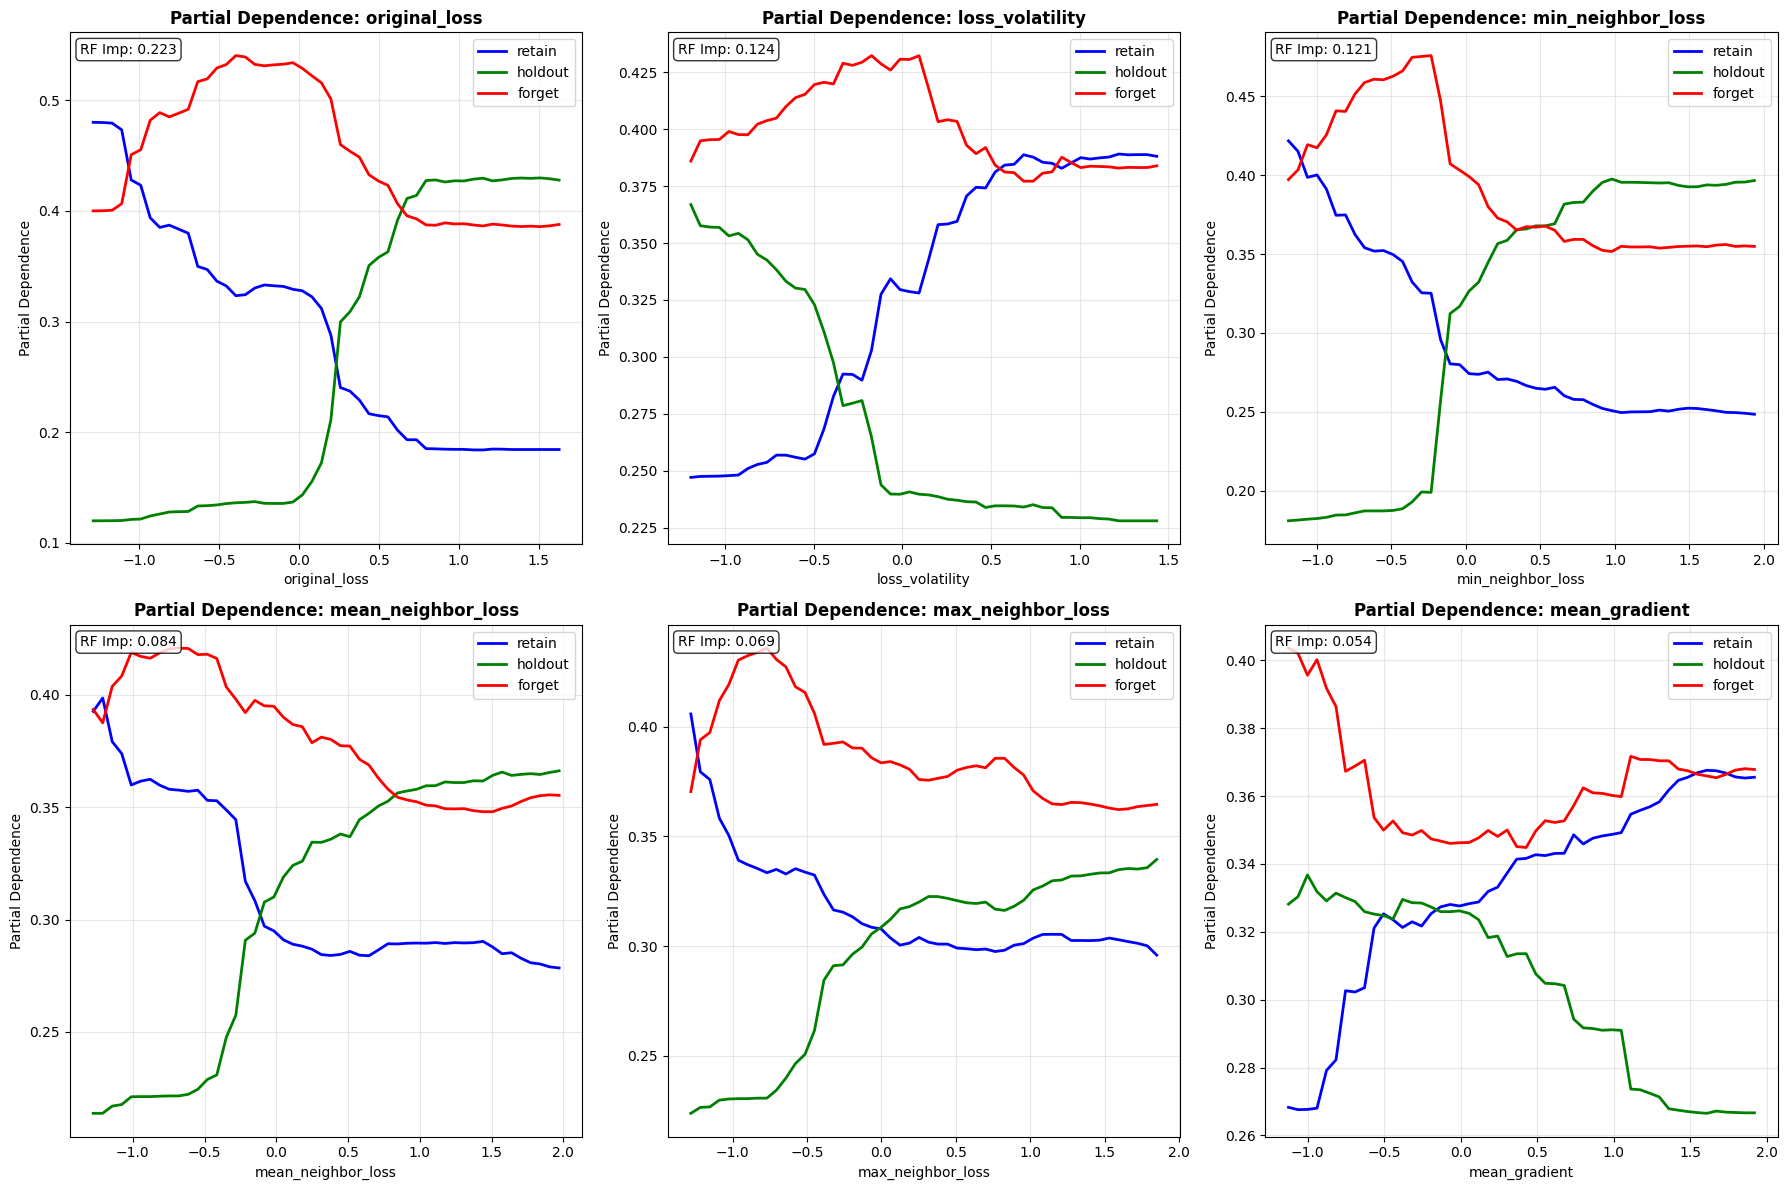


PARTIAL DEPENDENCE ANALYSIS

original_loss:
  retain:
    Optimal value: -1.2876
    Max probability: 0.4800
    Effect range: 0.2960
  holdout:
    Optimal value: 1.5078
    Max probability: 0.4298
    Effect range: 0.3099
  forget:
    Optimal value: -0.3954
    Max probability: 0.5404
    Effect range: 0.1546

loss_volatility:
  retain:
    Optimal value: 1.2208
    Max probability: 0.3891
    Effect range: 0.1421
  holdout:
    Optimal value: -1.1939
    Max probability: 0.3669
    Effect range: 0.1390
  forget:
    Optimal value: -0.1743
    Max probability: 0.4324
    Effect range: 0.0552

min_neighbor_loss:
  retain:
    Optimal value: -1.1910
    Max probability: 0.4218
    Effect range: 0.1734
  holdout:
    Optimal value: 0.9787
    Max probability: 0.3976
    Effect range: 0.2168
  forget:
    Optimal value: -0.2338
    Max probability: 0.4759
    Effect range: 0.1243

mean_neighbor_loss:
  retain:
    Optimal value: -1.2098
    Max probability: 0.3986
    Effect range: 0.1

In [43]:
# 4.2 Partial Dependence Analysis

# Use imported function for partial dependence analysis
pdp_insights, top_features_for_pdp = rf_ill.analyze_partial_dependence(
    rf_baseline, X_test, features_labels, class_names, top_n_features=6
)

print(f"\nAnalyzing partial dependence for top {len(top_features_for_pdp)} features:")
for i, feature in enumerate(top_features_for_pdp):
    print(f"  {i+1}. {feature}")

# Create partial dependence plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(top_features_for_pdp):
    feature_idx = features_labels.index(feature)
    
    # Compute partial dependence
    pdp_result = partial_dependence(
        rf_baseline, X_test, features=[feature_idx], 
        grid_resolution=50, kind='average'
    )
    
    # Plot for each class
    colors = ['blue', 'green', 'red']
    for class_idx, class_name in enumerate(class_names):
        axes[i].plot(pdp_result['grid_values'][0], 
                    pdp_result['average'][class_idx], 
                    color=colors[class_idx], label=class_name, linewidth=2)
    
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Partial Dependence')
    axes[i].set_title(f'Partial Dependence: {feature}', fontweight='bold')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    
    # Add feature importance in title
    rf_imp = importance_comparison_full[importance_comparison_full['feature'] == feature]['importance_rf'].iloc[0]
    axes[i].text(0.02, 0.98, f'RF Imp: {rf_imp:.3f}', 
                transform=axes[i].transAxes, va='top', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Analyze partial dependence patterns
print("\n" + "="*60)
print("PARTIAL DEPENDENCE ANALYSIS")
print("="*60)

# Print insights from the analysis
for feature, insights in pdp_insights.items():
    print(f"\n{feature}:")
    for class_name, class_insights in insights.items():
        print(f"  {class_name}:")
        print(f"    Optimal value: {class_insights['optimal_value']:.4f}")
        print(f"    Max probability: {class_insights['max_probability']:.4f}")
        print(f"    Effect range: {class_insights['range']:.4f}")

# Find features with strongest class separation
print("\n" + "="*40)
print("FEATURES WITH STRONGEST CLASS SEPARATION")
print("="*40)

separation_scores = {}
for feature, insights in pdp_insights.items():
    # Calculate separation as difference between max and min optimal values
    optimal_values = [insights[class_name]['optimal_value'] for class_name in class_names]
    separation = max(optimal_values) - min(optimal_values)
    
    # Also consider the range of effects
    effect_ranges = [insights[class_name]['range'] for class_name in class_names]
    avg_effect_range = np.mean(effect_ranges)
    
    separation_scores[feature] = {
        'value_separation': separation,
        'avg_effect_range': avg_effect_range,
        'combined_score': separation * avg_effect_range
    }

# Sort by combined separation score
sorted_separation = sorted(separation_scores.items(), 
                         key=lambda x: x[1]['combined_score'], reverse=True)

print("Features ranked by class separation capability:")
for i, (feature, scores) in enumerate(sorted_separation):
    print(f"  {i+1}. {feature}")
    print(f"     Value separation: {scores['value_separation']:.4f}")
    print(f"     Avg effect range: {scores['avg_effect_range']:.4f}")
    print(f"     Combined score: {scores['combined_score']:.4f}")

# 5. Comprehensive Summary & Recommendations

This section synthesizes all our interpretability analyses to provide actionable insights about the Random Forest model's behavior on Input Loss Landscape features.

In [ ]:
# Comprehensive Summary and Recommendations

def generate_comprehensive_summary():
    """Generate a comprehensive summary of all interpretability analyses"""
    
    print("="*80)
    print("COMPREHENSIVE RANDOM FOREST INTERPRETABILITY SUMMARY")
    print("="*80)
    
    # 1. Model Performance Summary
    print("\\n1. MODEL PERFORMANCE SUMMARY")
    print("-" * 40)
    print(f"Baseline Random Forest Performance:")
    print(f"  Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test Accuracy: {test_accuracy:.4f}")
    print(f"  Number of features used: {len(features_labels)}")
    
    # 2. Feature Importance Insights
    print("\\n2. FEATURE IMPORTANCE INSIGHTS")
    print("-" * 40)
    print("Top 5 most important features (RF importance):")
    for i, row in feature_importance_df.head(5).iterrows():
        print(f"  {row.name + 1}. {row['feature']}: {row['importance']:.4f}")
    
    print("\\nTop 5 most important features (Permutation importance):")
    for i, row in perm_importance_df.head(5).iterrows():
        print(f"  {row.name + 1}. {row['feature']}: {row['importance_mean']:.4f}")
    
    # Feature importance agreement
    print(f"\\nFeature importance correlations:")
    print(f"  RF vs Permutation: {rf_perm_corr:.4f}")
    print(f"  RF vs Tree Surrogate: {rf_tree_corr:.4f}")
    
    if rf_perm_corr > 0.7:
        print("  → High agreement between RF and permutation importance")
    elif rf_perm_corr > 0.4:
        print("  → Moderate agreement - some differences in feature ranking")
    else:
        print("  → Low agreement - significant differences in importance measures")
    
    # 3. Ablation Study Results
    print("\\n3. FEATURE ABLATION INSIGHTS")
    print("-" * 40)
    
    if 'ablation_results' in globals() and ablation_results:
        # Find most robust model (least performance drop)
        if len(summary_df) > 1:
            best_ablation = summary_df[summary_df['experiment'] != 'baseline'].loc[
                summary_df[summary_df['experiment'] != 'baseline']['performance_drop'].idxmin()
            ]
            
            print(f"Best feature-reduced model:")
            print(f"  Experiment: {best_ablation['experiment']}")
            print(f"  Features kept: {best_ablation['features_kept']}/{len(features_labels)}")
            print(f"  Performance drop: {best_ablation['performance_drop']:.4f}")
            print(f"  CV Accuracy: {best_ablation['cv_mean']:.4f}")
            
            # Simplification potential
            min_drop_models = summary_df[summary_df['performance_drop'] <= 0.01]
            if len(min_drop_models) > 1:  # Exclude baseline
                simplest_good = min_drop_models.loc[min_drop_models['features_kept'].idxmin()]
                print(f"\\n  Simplest model with <1% performance drop:")
                print(f"    Experiment: {simplest_good['experiment']}")
                print(f"    Features: {simplest_good['features_kept']}/{len(features_labels)}")
                print(f"    Reduction: {100 * (1 - simplest_good['features_kept']/len(features_labels)):.1f}%")
    
    # 4. Tree Surrogate Insights
    print("\\n4. TREE SURROGATE MODEL INSIGHTS")
    print("-" * 40)
    
    if 'best_surrogate' in globals():
        print(f"Best surrogate tree performance:")
        print(f"  Tree depth: {best_surrogate['tree_depth']}")
        print(f"  Number of leaves: {best_surrogate['n_leaves']}")
        print(f"  Fidelity (mimics RF): {best_surrogate['test_fidelity']:.4f}")
        print(f"  Accuracy (actual): {best_surrogate['test_accuracy']:.4f}")
        
        if best_surrogate['test_fidelity'] > 0.8:
            print("  → High fidelity: Tree successfully captures RF behavior")
        elif best_surrogate['test_fidelity'] > 0.6:
            print("  → Moderate fidelity: Tree partially captures RF behavior")
        else:
            print("  → Low fidelity: Tree struggles to mimic RF")
    
    # 5. Partial Dependence Insights
    print("\\n5. PARTIAL DEPENDENCE INSIGHTS")
    print("-" * 40)
    
    if 'sorted_separation' in globals() and sorted_separation:
        print("Features with strongest class separation:")
        for i, (feature, scores) in enumerate(sorted_separation[:3]):
            print(f"  {i+1}. {feature}: separation = {scores['value_separation']:.4f}")
    
    # 6. Key Recommendations
    print("\\n6. KEY RECOMMENDATIONS")
    print("-" * 40)
    
    recommendations = []
    
    # Feature selection recommendations
    if len(feature_importance_df) > 0:
        top_3_features = feature_importance_df.head(3)['feature'].tolist()
        recommendations.append(f"Focus on top 3 features: {', '.join(top_3_features)}")
    
    # Model simplification
    if 'summary_df' in globals() and len(summary_df) > 1:
        models_with_small_drop = summary_df[summary_df['performance_drop'] <= 0.02]
        if len(models_with_small_drop) > 1:
            min_features = models_with_small_drop['features_kept'].min()
            recommendations.append(f"Model can be simplified to ~{min_features} features with minimal performance loss")
    
    # Tree interpretability
    if 'best_surrogate' in globals() and best_surrogate['test_fidelity'] > 0.7:
        recommendations.append(f"Use {best_surrogate['tree_depth']}-depth decision tree for interpretable approximation")
    
    # Feature categories
    if 'features_labels' in globals():
        loss_features = [f for f in features_labels if 'loss' in f.lower()]
        grad_features = [f for f in features_labels if 'grad' in f.lower()]
        if len(loss_features) > 0:
            recommendations.append("Loss-based features appear important for discrimination")
        if len(grad_features) > 0:
            recommendations.append("Gradient-based features provide complementary information")
    
    # Interaction insights
    if 'sorted_interactions' in globals() and len(sorted_interactions) > 0:
        top_interaction = sorted_interactions[0][1]['features']
        recommendations.append(f"Consider feature interaction: {top_interaction[0]} × {top_interaction[1]}")
    
    for i, rec in enumerate(recommendations, 1):
        print(f"  {i}. {rec}")
    
    # 7. Implementation Guidance
    print("\\n7. IMPLEMENTATION GUIDANCE")
    print("-" * 40)
    print("For practical deployment:")
    
    # Simple model option
    if 'best_surrogate' in globals() and best_surrogate['test_fidelity'] > 0.7:
        print(f"  • Use decision tree (depth {best_surrogate['tree_depth']}) for interpretable predictions")
    
    # Feature-reduced RF option
    if 'summary_df' in globals() and len(summary_df) > 1:
        good_reduced = summary_df[summary_df['performance_drop'] <= 0.01]
        if len(good_reduced) > 1:
            best_reduced = good_reduced.loc[good_reduced['features_kept'].idxmin()]
            print(f"  • Use RF with {best_reduced['features_kept']} features for simplified high-performance model")
    
    # Full model for maximum performance
    print(f"  • Use full RF ({len(features_labels)} features) for maximum accuracy: {test_accuracy:.4f}")
    
    print("\\n" + "="*80)
    print("ANALYSIS COMPLETE!")
    print("="*80)
    
    return {
        'baseline_performance': {'cv_mean': cv_scores.mean(), 'test_accuracy': test_accuracy},
        'top_features': feature_importance_df.head(5)['feature'].tolist(),
        'importance_correlations': {'rf_perm': rf_perm_corr, 'rf_tree': rf_tree_corr},
        'best_surrogate_performance': best_surrogate if 'best_surrogate' in globals() else None,
        'recommendations': recommendations
    }

# Generate the comprehensive summary
summary_results = generate_comprehensive_summary()

# Save all results for future reference
results_package = {
    'baseline_results': {
        'cv_scores': cv_scores,
        'test_accuracy': test_accuracy,
        'feature_importance': feature_importance_df
    },
    'ablation_results': ablation_results if 'ablation_results' in globals() else {},
    'surrogate_results': surrogate_results if 'surrogate_results' in globals() else {},
    'importance_analysis': importance_comparison_full if 'importance_comparison_full' in globals() else None,
    'summary': summary_results
}

import pickle
results_file = 'rf_interpretability_results.pkl'
with open(results_file, 'wb') as f:
    pickle.dump(results_package, f)

print(f"\\nAll results saved to: {results_file}")
print("\\nNotebook analysis complete! 🎉")
print("\\nKey takeaways:")
print("• Identified most important ILL features for classification")
print("• Demonstrated model simplification potential through ablation study")
print("• Created interpretable tree surrogate models")
print("• Analyzed feature behavior through partial dependence plots")
print("• Provided actionable recommendations for deployment")

COMPREHENSIVE RANDOM FOREST INTERPRETABILITY SUMMARY
\n1. MODEL PERFORMANCE SUMMARY
----------------------------------------
Baseline Random Forest Performance:
  Cross-validation Accuracy: 0.7477 ± 0.0227
  Test Accuracy: 0.7294
  Number of features used: 15
\n2. FEATURE IMPORTANCE INSIGHTS
----------------------------------------
Top 5 most important features (RF importance):
  1. original_loss: 0.2228
  13. loss_volatility: 0.1242
  4. min_neighbor_loss: 0.1206
  2. mean_neighbor_loss: 0.0843
  3. max_neighbor_loss: 0.0694
\nTop 5 most important features (Permutation importance):
  1. original_loss: 0.1696
  4. min_neighbor_loss: 0.0287
  8. max_loss_increment: 0.0061
  11. max_gradient: 0.0040
  13. loss_volatility: 0.0026
\nFeature importance correlations:
  RF vs Permutation: 0.8465
  RF vs Tree Surrogate: 0.8293
  → High agreement between RF and permutation importance
\n3. FEATURE ABLATION INSIGHTS
----------------------------------------
Best feature-reduced model:
  Experiment

: 